# Fresh and Rotten Fruits Classification — Research Paper Reproduction

**Paper basis:** *Fresh and Rotten Fruits Classification Using CNN and Transfer Learning* by Sai Sudha Sonali Palakodati et al. (2020).

**224×224×3 input, six classes (fresh/rotten apple, banana and orange), 60/10/30 train/validation/test split, a three-convolution custom CNN, and comparison with VGG16, VGG19, MobileNet and Xception**.


## 1. Paper-to-notebook specification

| Item | Research paper |
|---|---|
| Fruits | Apple, Banana, Orange |
| Classes | 6: Fresh/Rotten for each fruit |
| Input size | 224 × 224 × 3 |
| Custom CNN | 3 convolution layers |
| Conv filters | 16, 16, 16 |
| Kernel sizes | 3×3, 5×5, 7×7 |
| Pooling | MaxPool 2×2 |
| Batch normalization | After each convolution, before ReLU |
| Dropout | 0.5 |
| Initializer | RandomUniform(-0.05, 0.05) |
| Regularizers | Kernel and bias regularizer = 0.05 |
| Loss | Categorical cross-entropy |
| Optimizer | Adam |
| Learning rate | 0.0001 |
| Batch size | 16 |
| Epochs | 100 |
| Transfer models | VGG16, VGG19, MobileNet, Xception |

The paper also reports hyperparameter experiments for batch size, epochs, optimizer and learning rate. Those experiments are included as **optional cells** so the main reproduction does not require running every expensive experiment.

## 2. Environment and imports

In [1]:
import os
import random
import shutil
import zipfile
import subprocess
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, initializers
from tensorflow.keras.applications import VGG16, VGG19, MobileNet, Xception
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess
from tensorflow.keras.applications.vgg19 import preprocess_input as vgg19_preprocess
from tensorflow.keras.applications.mobilenet import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.xception import preprocess_input as xception_preprocess

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU(s):", tf.config.list_physical_devices("GPU"))
if tf.config.list_physical_devices("GPU"):
    print("GPU is available. For the paper's long training, Colab GPU is recommended.")
else:
    print("No GPU detected. The 225-epoch reproduction may be very slow.")

TensorFlow: 2.20.0
GPU(s): [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU is available. For the paper's long training, Colab GPU is recommended.


## 3. Configuration

The Kaggle URL below is the same dataset source used by the existing project. If your downloaded dataset is stored elsewhere, change `DATA_ROOT` and skip the download/extraction cells.

In [30]:
KAGGLE_URL = "https://www.kaggle.com/api/v1/datasets/download/sriramr/fruits-fresh-and-rotten-for-classification"

ZIP_PATH = "/content/fruits-fresh-and-rotten.zip"
EXTRACT_PATH = "/content/fruit_dataset"

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
NUM_CLASSES_EXPECTED = 6

# Main paper reproduction settings
PAPER_EPOCHS = 100
PAPER_LR = 1e-4
DROPOUT_RATE = 0.5

# Set True only when you want to train the transfer-learning comparison models.
RUN_TRANSFER_MODELS = False

# Set True only when you want to run the expensive hyperparameter experiments.
RUN_HYPERPARAMETER_EXPERIMENTS = False

# Optional: cap epochs for a quick sanity check. Set to None for the paper value.
QUICK_EPOCHS = None

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Paper epochs:", PAPER_EPOCHS)
print("Paper learning rate:", PAPER_LR)

Image size: (224, 224)
Batch size: 16
Paper epochs: 100
Paper learning rate: 0.0001


## 4. Download the dataset

The paper states that the dataset was obtained from Kaggle. This cell downloads the dataset used by the existing notebook.

In [3]:
def valid_zip(path):
    if not os.path.exists(path) or os.path.getsize(path) < 1024:
        return False
    try:
        with zipfile.ZipFile(path, "r") as z:
            return z.testzip() is None
    except zipfile.BadZipFile:
        return False

if valid_zip(ZIP_PATH):
    print("Valid dataset ZIP already exists:", ZIP_PATH)
else:
    if os.path.exists(ZIP_PATH):
        os.remove(ZIP_PATH)
    print("Downloading dataset...")
    result = subprocess.run(["wget", "-q", "-O", ZIP_PATH, KAGGLE_URL], text=True)
    if result.returncode != 0 or not valid_zip(ZIP_PATH):
        raise RuntimeError("Dataset download failed. Check the URL or upload the dataset manually.")
    print("Download completed.")

Download completed.


## 5. Extract and locate the six class folders

In [4]:
os.makedirs(EXTRACT_PATH, exist_ok=True)

if not any(os.scandir(EXTRACT_PATH)):
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(EXTRACT_PATH)
    print("Dataset extracted.")
else:
    print("Extraction directory already contains files.")

IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

def find_class_parent(root):
    candidates = []
    for current_root, dirs, files in os.walk(root):
        subdirs = [d for d in dirs if os.path.isdir(os.path.join(current_root, d))]
        if len(subdirs) >= 6:
            image_counts = []
            for d in subdirs:
                folder = os.path.join(current_root, d)
                count = sum(
                    1 for f in os.listdir(folder)
                    if f.lower().endswith(IMAGE_EXTENSIONS)
                )
                image_counts.append((d, count))
            if sum(c > 0 for _, c in image_counts) >= 6:
                candidates.append((current_root, image_counts))
    if not candidates:
        raise FileNotFoundError(
            "Could not automatically find the six class folders. "
            "Inspect EXTRACT_PATH and set DATA_ROOT manually."
        )
    # Prefer the shallowest candidate with exactly six useful folders.
    candidates.sort(key=lambda x: (x[0].count(os.sep), -sum(c > 0 for _, c in x[1])))
    return candidates[0][0]

DATA_ROOT = find_class_parent(EXTRACT_PATH)
CLASS_NAMES = sorted([
    d for d in os.listdir(DATA_ROOT)
    if os.path.isdir(os.path.join(DATA_ROOT, d))
    and any(f.lower().endswith(IMAGE_EXTENSIONS) for f in os.listdir(os.path.join(DATA_ROOT, d)))
])

print("DATA_ROOT:", DATA_ROOT)
print("Classes:", CLASS_NAMES)

if len(CLASS_NAMES) != NUM_CLASSES_EXPECTED:
    raise ValueError(
        f"Expected 6 classes, found {len(CLASS_NAMES)}: {CLASS_NAMES}. "
        "Set DATA_ROOT to the folder containing the six class directories."
    )

Dataset extracted.
DATA_ROOT: /content/fruit_dataset/dataset/test
Classes: ['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']


## 6. Inspect class distribution

In [5]:
rows = []
all_paths, all_labels = [], []

for label, cls in enumerate(CLASS_NAMES):
    folder = os.path.join(DATA_ROOT, cls)
    files = sorted([
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if f.lower().endswith(IMAGE_EXTENSIONS)
    ])
    rows.append({"Class": cls, "Images": len(files)})
    all_paths.extend(files)
    all_labels.extend([label] * len(files))

distribution_df = pd.DataFrame(rows)
display(distribution_df)

print("Total images found:", len(all_paths))
print("Paper total       :", 5989)

,Class,Images
0,freshapples,395
1,freshbanana,381
2,freshoranges,388
3,rottenapples,601
4,rottenbanana,530
5,rottenoranges,403


Total images found: 2698
Paper total       : 5989


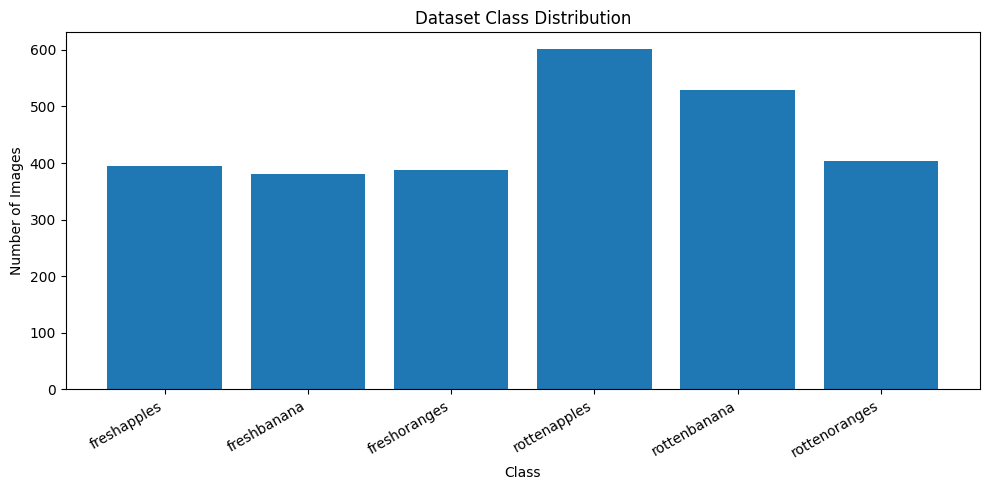

In [13]:
plt.figure(figsize=(10, 5))
plt.bar(distribution_df["Class"], distribution_df["Images"])
plt.title("Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 7. Display sample images

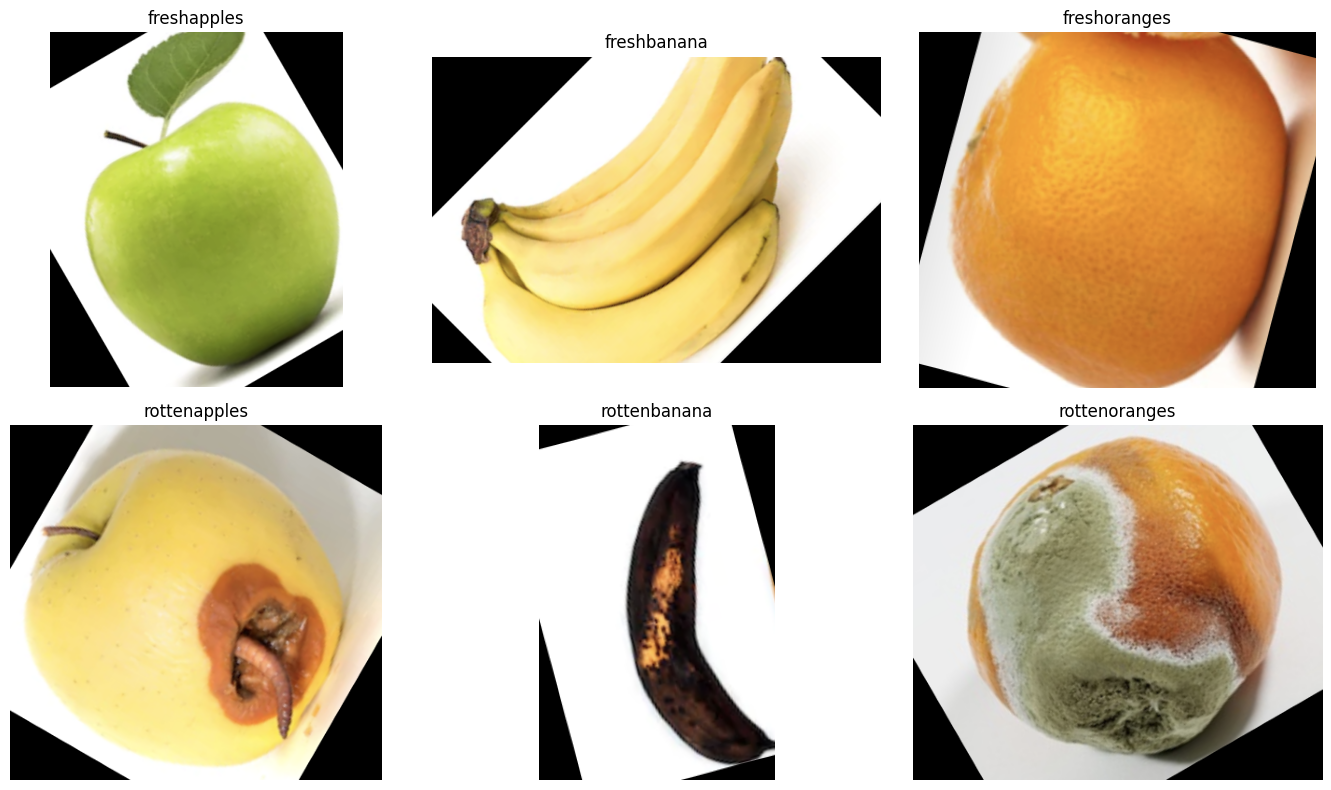

In [31]:
plt.figure(figsize=(14, 8))

for i, cls in enumerate(CLASS_NAMES):
    folder = os.path.join(DATA_ROOT, cls)
    files = [
        os.path.join(folder, f) for f in os.listdir(folder)
        if f.lower().endswith(IMAGE_EXTENSIONS)
    ]
    path = random.choice(files)
    image = Image.open(path).convert("RGB")

    ax = plt.subplot(2, 3, i + 1)
    ax.imshow(image)
    ax.set_title(cls)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 8. Create the paper's 60% / 10% / 30% stratified split



In [32]:
paths = np.array(all_paths)
labels = np.array(all_labels)

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    paths, labels,
    test_size=0.40,
    stratify=labels,
    random_state=SEED
)

# 25% of the remaining 40% = 10% of the complete dataset.
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels,
    test_size=0.75,
    stratify=temp_labels,
    random_state=SEED
)

split_df = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Images": [len(train_paths), len(val_paths), len(test_paths)],
    "Percentage": [
        len(train_paths)/len(paths)*100,
        len(val_paths)/len(paths)*100,
        len(test_paths)/len(paths)*100
    ]
})
display(split_df)

print("Paper reported: Train=3596, Validation=596, Test=1797, Total=5989")

,Split,Images,Percentage
0,Train,1618,59.970348
1,Validation,270,10.007413
2,Test,810,30.022239


Paper reported: Train=3596, Validation=596, Test=1797, Total=5989


## 9. Build TensorFlow datasets

The paper reshapes images to **224×224×3** and converts them to arrays. We perform the same spatial resizing while keeping the input pipeline memory-efficient.

In [33]:
AUTOTUNE = tf.data.AUTOTUNE

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label

def make_dataset(paths, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(min(len(paths), 2048), seed=SEED, reshuffle_each_iteration=True)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds_int = make_dataset(train_paths, train_labels, shuffle=True)
val_ds_int = make_dataset(val_paths, val_labels, shuffle=False)
test_ds_int = make_dataset(test_paths, test_labels, shuffle=False)

# One-hot datasets for categorical cross-entropy, as used in the paper.
def one_hot_dataset(ds):
    return ds.map(
        lambda x, y: (x, tf.one_hot(y, depth=len(CLASS_NAMES))),
        num_parallel_calls=AUTOTUNE
    ).prefetch(AUTOTUNE)

train_ds = one_hot_dataset(train_ds_int)
val_ds = one_hot_dataset(val_ds_int)
test_ds = one_hot_dataset(test_ds_int)

print("Datasets ready.")

Datasets ready.


## 10. Paper CNN architecture

The proposed model contains three convolutional layers:

1. 16 filters, 3×3 kernel
2. 16 filters, 5×5 kernel
3. 16 filters, 7×7 kernel

Each convolution is followed by batch normalization, ReLU, 2×2 max pooling and dropout 0.5. The paper specifies a fully connected layer after flattening, but does **not state the number of neurons in that dense layer**. This implementation uses 128 neurons as a clearly marked implementation choice, followed by the six-class Softmax output.

It also reports RandomUniform(-0.05, 0.05) initialization and regularization value 0.05.

In [34]:
PAPER_INIT = initializers.RandomUniform(minval=-0.05, maxval=0.05, seed=SEED)
PAPER_REG = regularizers.l2(0.05)

def build_paper_cnn(dense_units=128):
    inputs = keras.Input(shape=(*IMG_SIZE, 3), name="input_image")
    x = layers.Rescaling(1.0 / 255.0, name="rescale")(inputs)

    for filters, kernel, block in [
        (16, 3, 1),
        (16, 5, 2),
        (16, 7, 3),
    ]:
        x = layers.Conv2D(
            filters=filters,
            kernel_size=(kernel, kernel),
            padding="valid",  # paper states no padding
            kernel_initializer=PAPER_INIT,
            kernel_regularizer=PAPER_REG,
            bias_regularizer=PAPER_REG,
            name=f"conv{block}_{kernel}x{kernel}"
        )(x)
        x = layers.BatchNormalization(name=f"batchnorm{block}")(x)
        x = layers.ReLU(name=f"relu{block}")(x)
        x = layers.MaxPooling2D(pool_size=(2, 2), name=f"maxpool{block}")(x)
        x = layers.Dropout(DROPOUT_RATE, name=f"dropout{block}")(x)

    x = layers.Flatten(name="flatten")(x)
    x = layers.Dense(
        dense_units,
        activation="relu",
        kernel_initializer=PAPER_INIT,
        kernel_regularizer=PAPER_REG,
        bias_regularizer=PAPER_REG,
        name="fully_connected"
    )(x)
    x = layers.Dropout(DROPOUT_RATE, name="fc_dropout")(x)
    outputs = layers.Dense(
        len(CLASS_NAMES),
        activation="softmax",
        name="softmax_output"
    )(x)

    model = keras.Model(inputs, outputs, name="Paper_Proposed_CNN")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=PAPER_LR),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

cnn_model = build_paper_cnn()
cnn_model.summary()

Model: "Paper_Proposed_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescale (Rescaling)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_3x3 (Conv2D)              │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm1 (BatchNormalization) │ (None, 222, 222, 16)   │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (ReLU)                    │ (None, 222, 222, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool1 (MaxPooling2D)         │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_5x5 (Conv2D)              │ (None, 107, 107, 16)   │         6,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm2 (BatchNormalization) │ (None, 107, 107, 16)   │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (ReLU)                    │ (None, 107, 107, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2 (MaxPooling2D)         │ (None, 53, 53, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 53, 53, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_7x7 (Conv2D)              │ (None, 47, 47, 16)     │        12,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm3 (BatchNormalization) │ (None, 47, 47, 16)     │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3 (ReLU)                    │ (None, 47, 47, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool3 (MaxPooling2D)         │ (None, 23, 23, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout3 (Dropout)              │ (None, 23, 23, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8464)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fully_connected (Dense)         │ (None, 128)            │     1,083,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_dropout (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_output (Dense)          │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,103,910 (4.21 MB)

 Trainable params: 1,103,814 (4.21 MB)

 Non-trainable params: 96 (384.00 B)

## 11. Train the proposed CNN

 learning rate 0.0001, batch size 16 and 100 epochs.
No early stopping is used in the main reproduction because the paper explicitly reports 100 epochs. If you only want to verify that the notebook runs, set `QUICK_EPOCHS` above to a small number.

In [35]:
epochs_to_run = PAPER_EPOCHS if QUICK_EPOCHS is None else QUICK_EPOCHS

start = time.time()
cnn_history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs_to_run,
    verbose=1
)
cnn_train_time = time.time() - start

print(f"Training time: {cnn_train_time/60:.2f} minutes")

Epoch 1/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 24s 115ms/step - accuracy: 0.2058 - loss: 47.6933 - val_accuracy: 0.1778 - val_loss: 44.3926
Epoch 2/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.2583 - loss: 42.5839 - val_accuracy: 0.2222 - val_loss: 40.5800
Epoch 3/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.3282 - loss: 38.4835 - val_accuracy: 0.2222 - val_loss: 36.5915
Epoch 4/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.3906 - loss: 34.3957 - val_accuracy: 0.3037 - val_loss: 32.7276
Epoch 5/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.4258 - loss: 30.5106 - val_accuracy: 0.2667 - val_loss: 28.9781
Epoch 6/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.4679 - loss: 26.8763 - val_accuracy: 0.3185 - val_loss: 25.3963
Epoch 7/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.5229 - loss: 23.5884 - val_accuracy: 0.3222 - val_loss: 22.3932
Epoch 8/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.561

## 12. Plot proposed-CNN learning curves

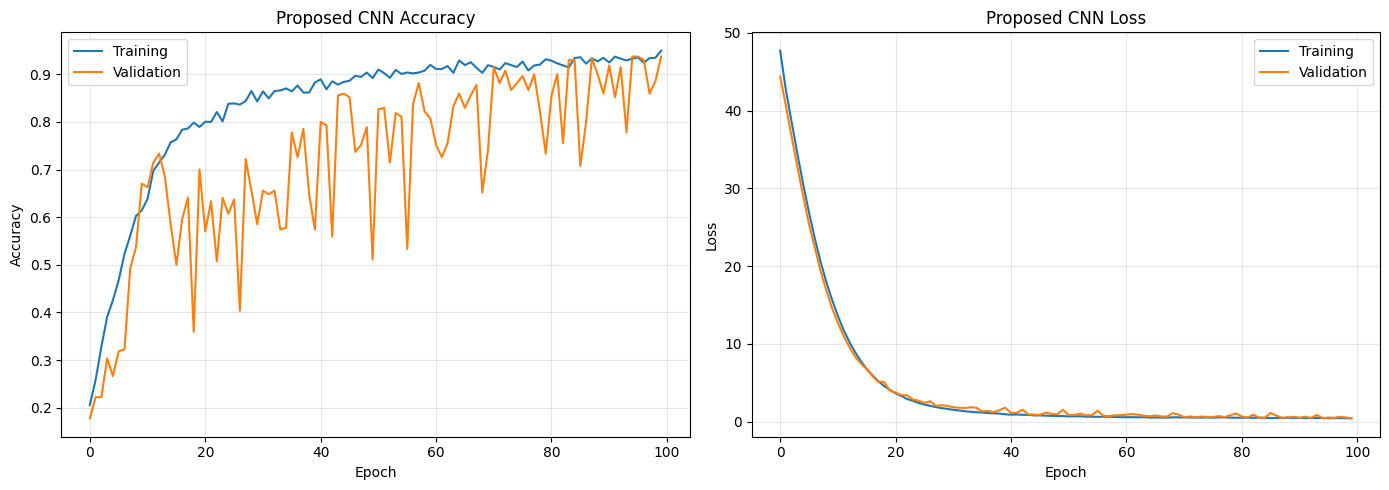

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cnn_history.history["accuracy"], label="Training")
axes[0].plot(cnn_history.history["val_accuracy"], label="Validation")
axes[0].set_title("Proposed CNN Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(cnn_history.history["loss"], label="Training")
axes[1].plot(cnn_history.history["val_loss"], label="Validation")
axes[1].set_title("Proposed CNN Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 13. Evaluate the proposed CNN on the untouched test set

In [37]:
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(test_ds, verbose=1)
print(f"Measured Proposed CNN Test Accuracy: {cnn_test_accuracy * 100:.2f}%")
print("Paper-reported Proposed CNN Accuracy: 97.82%")

51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - accuracy: 0.9111 - loss: 0.5216
Measured Proposed CNN Test Accuracy: 91.11%
Paper-reported Proposed CNN Accuracy: 97.82%


## 14. Detailed metrics and confusion matrix for the proposed CNN

,Metric,Score (%)
0,Accuracy,91.111111
1,Precision,91.459399
2,Recall,91.111111
3,F1-score,91.144345


               precision    recall  f1-score   support

  freshapples       0.97      0.82      0.89       118
  freshbanana       0.96      0.99      0.97       115
 freshoranges       0.92      0.95      0.93       116
 rottenapples       0.81      0.89      0.85       181
 rottenbanana       0.99      0.96      0.97       159
rottenoranges       0.87      0.86      0.87       121

     accuracy                           0.91       810
    macro avg       0.92      0.91      0.91       810
 weighted avg       0.91      0.91      0.91       810



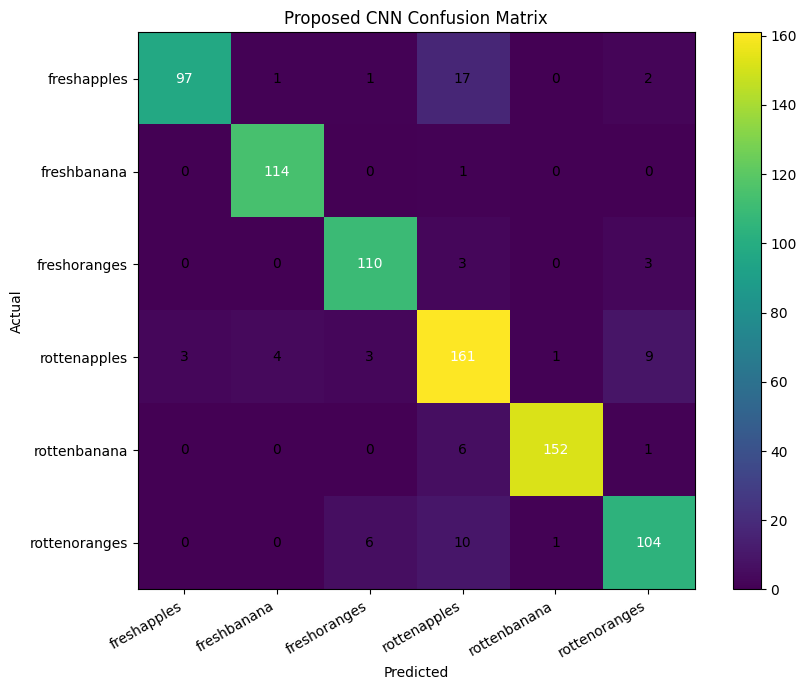

In [38]:
def collect_predictions(model, dataset):
    y_true, y_pred, y_prob = [], [], []
    for images, labels in dataset:
        probs = model.predict(images, verbose=0)
        y_true.extend(np.argmax(labels.numpy(), axis=1))
        y_pred.extend(np.argmax(probs, axis=1))
        y_prob.extend(probs)
    return np.array(y_true), np.array(y_pred), np.array(y_prob)

cnn_y_true, cnn_y_pred, cnn_y_prob = collect_predictions(cnn_model, test_ds)

cnn_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Score (%)": [
        accuracy_score(cnn_y_true, cnn_y_pred) * 100,
        precision_score(cnn_y_true, cnn_y_pred, average="weighted", zero_division=0) * 100,
        recall_score(cnn_y_true, cnn_y_pred, average="weighted", zero_division=0) * 100,
        f1_score(cnn_y_true, cnn_y_pred, average="weighted", zero_division=0) * 100
    ]
})
display(cnn_metrics)

print(classification_report(
    cnn_y_true, cnn_y_pred,
    target_names=CLASS_NAMES,
    zero_division=0
))

cm = confusion_matrix(cnn_y_true, cnn_y_pred)

plt.figure(figsize=(9, 7))
plt.imshow(cm)
plt.title("Proposed CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(range(len(CLASS_NAMES)), CLASS_NAMES, rotation=30, ha="right")
plt.yticks(range(len(CLASS_NAMES)), CLASS_NAMES)

threshold = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]),
                 ha="center", va="center",
                 color="white" if cm[i, j] > threshold else "black")

plt.colorbar()
plt.tight_layout()
plt.show()

# 15. Transfer-learning comparison

The paper compares the proposed CNN with **VGG16, VGG19, MobileNet and Xception**. The following function creates a six-class classifier on top of each pretrained feature extractor.

These models are **optional and computationally expensive**. Set `RUN_TRANSFER_MODELS = True` to run them.

In [39]:
def make_transfer_model(name):
    builders = {
        "VGG16": (VGG16, vgg16_preprocess),
        "VGG19": (VGG19, vgg19_preprocess),
        "MobileNet": (MobileNet, mobilenet_preprocess),
        "Xception": (Xception, xception_preprocess),
    }

    builder, preprocess = builders[name]

    base = builder(
        include_top=False,
        weights="imagenet",
        input_shape=(*IMG_SIZE, 3)
    )
    base.trainable = False

    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    x = preprocess(inputs)
    x = base(x, training=False)

    # The paper says the final classifier is replaced by 6 classes.
    x = layers.Flatten()(x)
    outputs = layers.Dense(len(CLASS_NAMES), activation="softmax")(x)

    model = keras.Model(inputs, outputs, name=f"{name}_Fruit_Classifier")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=PAPER_LR),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model, base

transfer_results = []

if RUN_TRANSFER_MODELS:
    for model_name in ["VGG16", "VGG19", "MobileNet", "Xception"]:
        print("\n" + "=" * 70)
        print("TRAINING", model_name)
        print("=" * 70)

        model, base = make_transfer_model(model_name)

        # The paper compares the models after replacing the final classifier.
        hist = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=epochs_to_run,
            verbose=1
        )

        loss, acc = model.evaluate(test_ds, verbose=1)
        transfer_results.append({
            "Model": model_name,
            "Measured Test Accuracy (%)": acc * 100
        })

        globals()[model_name.lower() + "_model"] = model

    transfer_df = pd.DataFrame(transfer_results)
    display(transfer_df)
else:
    print("Transfer-model training is OFF.")
    print("Set RUN_TRANSFER_MODELS = True and rerun this cell to train VGG16/VGG19/MobileNet/Xception.")

Transfer-model training is OFF.
Set RUN_TRANSFER_MODELS = True and rerun this cell to train VGG16/VGG19/MobileNet/Xception.


## 16. Compare measured results with the paper's reported transfer-learning accuracies

The paper reports the following accuracies: VGG16 89.42%, VGG19 76.18%, MobileNet 68.72%, Xception 78.68%, and Proposed CNN 97.82%.

The reported values are included **only as paper reference values**. Your measured values should be kept separate.

In [40]:
paper_results = pd.DataFrame({
    "Model": ["VGG16", "VGG19", "MobileNet", "Xception", "Proposed CNN"],
    "Paper Reported Accuracy (%)": [89.42, 76.18, 68.72, 78.68, 97.82]
})

if RUN_TRANSFER_MODELS:
    measured_results = pd.concat([
        transfer_df,
        pd.DataFrame([{
            "Model": "Proposed CNN",
            "Measured Test Accuracy (%)": cnn_test_accuracy * 100
        }])
    ], ignore_index=True)

    comparison_df = paper_results.merge(measured_results, on="Model", how="left")
else:
    comparison_df = paper_results.copy()
    comparison_df["Measured Test Accuracy (%)"] = np.nan
    comparison_df.loc[
        comparison_df["Model"] == "Proposed CNN",
        "Measured Test Accuracy (%)"
    ] = cnn_test_accuracy * 100

display(comparison_df)

,Model,Paper Reported Accuracy (%),Measured Test Accuracy (%)
0,VGG16,89.42,NaN
1,VGG19,76.18,NaN
2,MobileNet,68.72,NaN
3,Xception,78.68,NaN
4,Proposed CNN,97.82,91.111112


# 17. Optional hyperparameter experiments from the paper
,
,The paper investigates:
,
,- Batch size: 8, 16, 32, 64
,- Epochs: 15, 25, 50, 75, 150, 225
,- Optimizer: SGD, Adam, Adagrad, RMSprop
,- Learning rate: 0.1, 0.01, 0.001, 0.0001
,
,The paper reports that batch size 16 gave the highest accuracy, 30 epochs gave 97.82%, Adam gave 97.82%, and learning rate 0.0001 gave 97.82%.
,
,Running all experiments is expensive. The code below is disabled by default and is intended for a research-style ablation study.

In [42]:
# WARNING: This cell can require many GPU-hours.
if RUN_HYPERPARAMETER_EXPERIMENTS:
    print("Hyperparameter experiments enabled.")
    print("For a full paper-style sweep, implement each experiment as a separate run")
    print("and record the resulting test accuracy in a CSV/DataFrame.")
else:
    print("Hyperparameter experiments are OFF.")
    print("This keeps the main notebook practical while preserving the paper's reported settings.")

Hyperparameter experiments are OFF.
This keeps the main notebook practical while preserving the paper's reported settings.


## 18. Save the trained proposed model

In [43]:
MODEL_PATH = "/content/proposed_fresh_rotten_fruit_cnn.keras"
cnn_model.save(MODEL_PATH)
print("Saved model:", MODEL_PATH)

Saved model: /content/proposed_fresh_rotten_fruit_cnn.keras


# 19. Predict a new fruit image

This section uses the **proposed CNN from the research paper reproduction**, not the old MobileNetV2 model from the original project.

In [51]:
from google.colab import files

uploaded = files.upload()
if not uploaded:
    raise ValueError("No image uploaded.")

uploaded_name = next(iter(uploaded))
print("Uploaded:", uploaded_name)

Saving fresh apple.jpg to fresh apple.jpg
Uploaded: fresh apple.jpg


In [52]:
image = tf.keras.utils.load_img(uploaded_name, target_size=IMG_SIZE)
image_array = tf.keras.utils.img_to_array(image)
batch = np.expand_dims(image_array, axis=0)

probabilities = cnn_model.predict(batch, verbose=0)[0]
predicted_index = int(np.argmax(probabilities))
predicted_class = CLASS_NAMES[predicted_index]
confidence = float(probabilities[predicted_index] * 100)

def get_fruit_name(label):
    label_lower = label.lower()
    if "apple" in label_lower:
        return "Apple"
    if "banana" in label_lower:
        return "Banana"
    if "orange" in label_lower:
        return "Orange"
    return "Unknown"

def get_condition(label):
    return "Fresh" if "fresh" in label.lower() else "Rotten"

fruit = get_fruit_name(predicted_class)
condition = get_condition(predicted_class)

print("=" * 60)
print("RESEARCH-PAPER CNN PREDICTION")
print("=" * 60)
print("Predicted class :", predicted_class)
print("Fruit           :", fruit)
print("Condition       :", condition)
print(f"Confidence      : {confidence:.2f}%")
print("=" * 60)

RESEARCH-PAPER CNN PREDICTION
Predicted class : freshapples
Fruit           : Apple
Condition       : Fresh
Confidence      : 76.46%


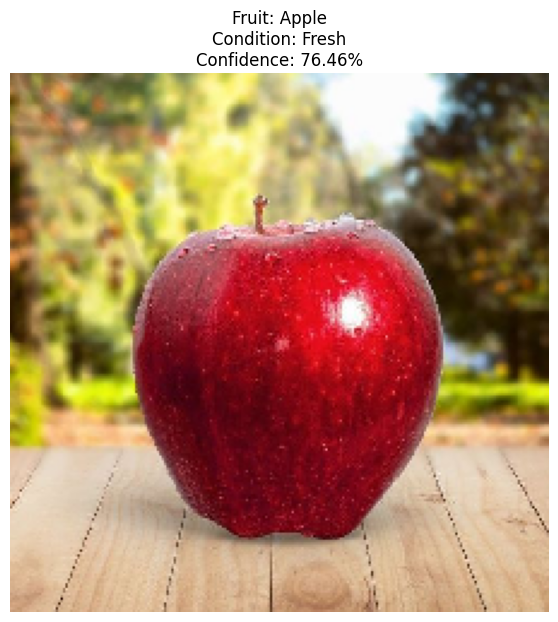

,Class,Probability (%)
0,freshapples,76.455223
3,rottenapples,11.505050
4,rottenbanana,8.404140
5,rottenoranges,2.264440
1,freshbanana,1.280292
2,freshoranges,0.090848


In [53]:
plt.figure(figsize=(7, 7))
plt.imshow(image)
plt.title(
    f"Fruit: {fruit}\n"
    f"Condition: {condition}\n"
    f"Confidence: {confidence:.2f}%"
)
plt.axis("off")
plt.show()

probability_df = pd.DataFrame({
    "Class": CLASS_NAMES,
    "Probability (%)": probabilities * 100
}).sort_values("Probability (%)", ascending=False)

display(probability_df)

# 20. Final results summary

Use this section after training to obtain the actual result for your report. **Do not write 97.82% as your achieved accuracy unless your run actually obtains it.** You can report 97.82% as the value reported by the research paper and your own measured value separately.

In [54]:
print("=" * 70)
print("RESEARCH PAPER REPRODUCTION SUMMARY")
print("=" * 70)
print("Dataset images found        :", len(paths))
print("Classes                      :", CLASS_NAMES)
print("Input size                   :", IMG_SIZE)
print("Train / Validation / Test   :", len(train_paths), "/", len(val_paths), "/", len(test_paths))
print("Optimizer                   : Adam")
print("Learning rate               :", PAPER_LR)
print("Batch size                  :", BATCH_SIZE)
print("Epochs used                 :", epochs_to_run)
print(f"Measured Proposed CNN Acc.  : {cnn_test_accuracy * 100:.2f}%")
print("Paper-reported CNN Acc.     : 97.82%")
print("=" * 70)

RESEARCH PAPER REPRODUCTION SUMMARY
Dataset images found        : 2698
Classes                      : ['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']
Input size                   : (224, 224)
Train / Validation / Test   : 1618 / 270 / 810
Optimizer                   : Adam
Learning rate               : 0.0001
Batch size                  : 16
Epochs used                 : 100
Measured Proposed CNN Acc.  : 91.11%
Paper-reported CNN Acc.     : 97.82%
